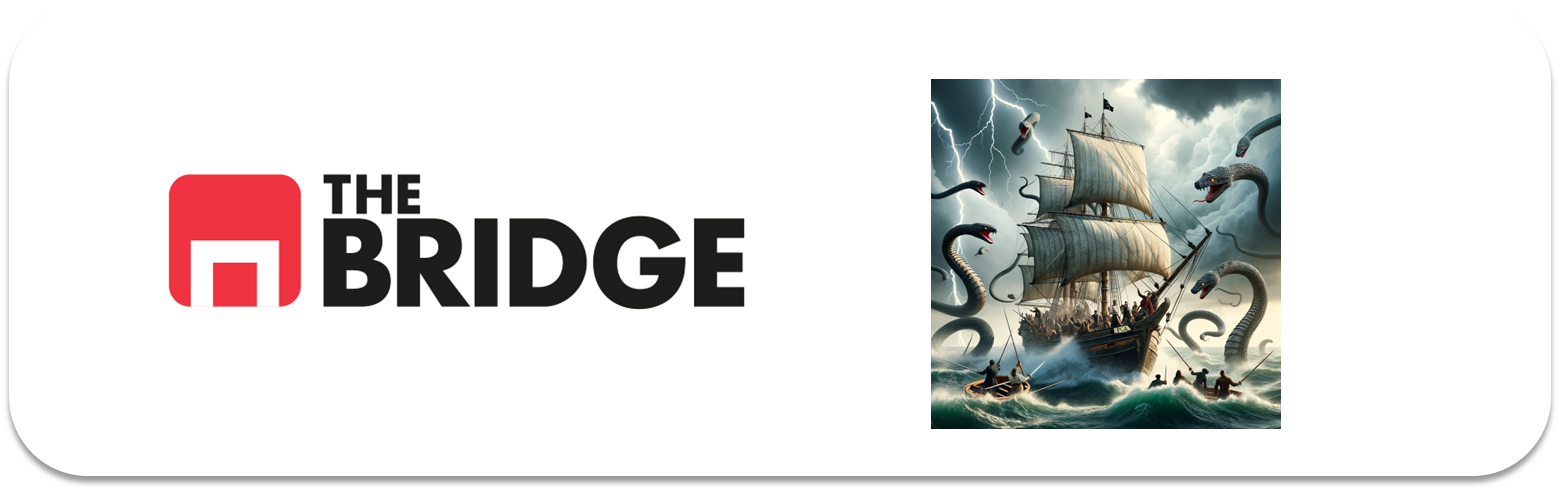

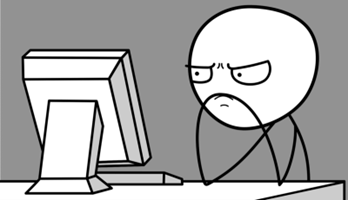

Para ejercitarte y afianzar lo aprendido sobre **PCA**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)

La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

# Principal Components Analysis: Nutrition
En esta colección de ejercicios no vas a montar ningún modelo de Machine Learning supervisado, sino que vas a practicar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlas, pintar y escoger número de componentes según varianza.


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples, balanced_accuracy_score,
                             accuracy_score, adjusted_rand_score, normalized_mutual_info_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from threadpoolctl import threadpool_limits
threadpool_limits(2)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

from sklearn.impute import SimpleImputer

### Ejercicio 1: Importa los datos
1. Importa los datos: *nutrition.csv*
2. Observa las columnas que hay, así como su tipo.

In [2]:
df=pd.read_csv('data/nutrition.csv')
display(df.head()); df.info()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


<class 'pandas.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   str    
 2   ShortDescrip      8618 non-null   str    
 3   Descrip           8618 non-null   str    
 4   CommonName        1063 non-null   str    
 5   MfgName           1560 non-null   str    
 6   ScientificName    732 non-null    str    
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64
 17  VitE_m

### Ejercicio 2


Analiza la correlación entre las variables numéricas. 

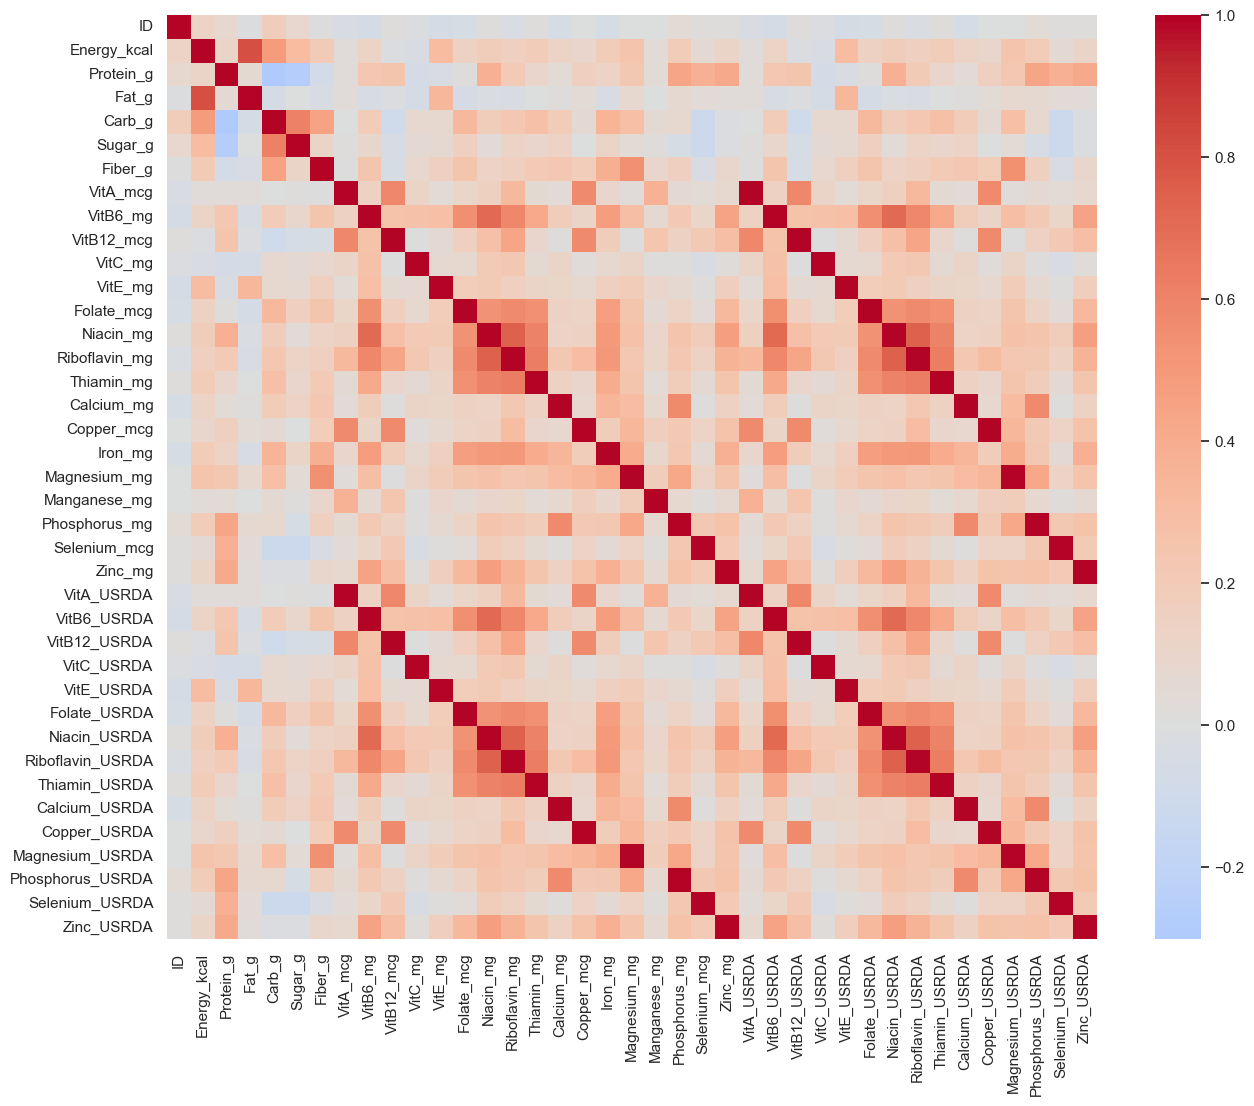

In [3]:
numeric=df.select_dtypes(include='number')
plt.figure(figsize=(15,12)); sns.heatmap(numeric.corr(),cmap='coolwarm',center=0); plt.show()

### Ejercicio 3

¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [4]:
usrda=[c for c in df if c.endswith('_USRDA')]
correlations=[]
for c in usrda:
    prefix=c.removesuffix('_USRDA')
    other=[x for x in numeric if x.startswith(prefix+'_') and x!=c and not x.endswith('_USRDA')]
    for x in other: correlations.append({'USRDA':c,'medida':x,'correlacion':df[c].corr(df[x])})
display(pd.DataFrame(correlations))
df=df.drop(columns=usrda+['ID'])
print('USRDA reexpresa la misma cantidad en unidades de ingesta diaria; duplicarla sobreponderaría nutrientes. ID no es una característica nutricional.')

,USRDA,medida,correlacion
0,VitA_USRDA,VitA_mcg,1.0
1,VitB6_USRDA,VitB6_mg,1.0
2,VitB12_USRDA,VitB12_mcg,1.0
3,VitC_USRDA,VitC_mg,1.0
4,VitE_USRDA,VitE_mg,1.0
5,Folate_USRDA,Folate_mcg,1.0
6,Niacin_USRDA,Niacin_mg,1.0
7,Riboflavin_USRDA,Riboflavin_mg,1.0
8,Thiamin_USRDA,Thiamin_mg,1.0
9,Calcium_USRDA,Calcium_mg,1.0


USRDA reexpresa la misma cantidad en unidades de ingesta diaria; duplicarla sobreponderaría nutrientes. ID no es una característica nutricional.


### Ejercicio 4: Variables Categóricas

Podríamos analizar las variables no numéricas del dataset e intentar obtener más información, pero por simplicidad en este caso procedemos a eliminarlas. Elimina las variables de texto del dataset.

In [5]:
X=df.select_dtypes(include='number').copy()
display(X.head())

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,0.0,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,0.0,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,0.0,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,0.0,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,0.0,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


### Ejercicio 5: Distribuciones

Analiza la distribución de las variables/columnas/features restantes. Recuerda que PCA es altamente sensible a las escala, así que transforma aquellas variables que creas necesario antes de proceder a escalarlas.


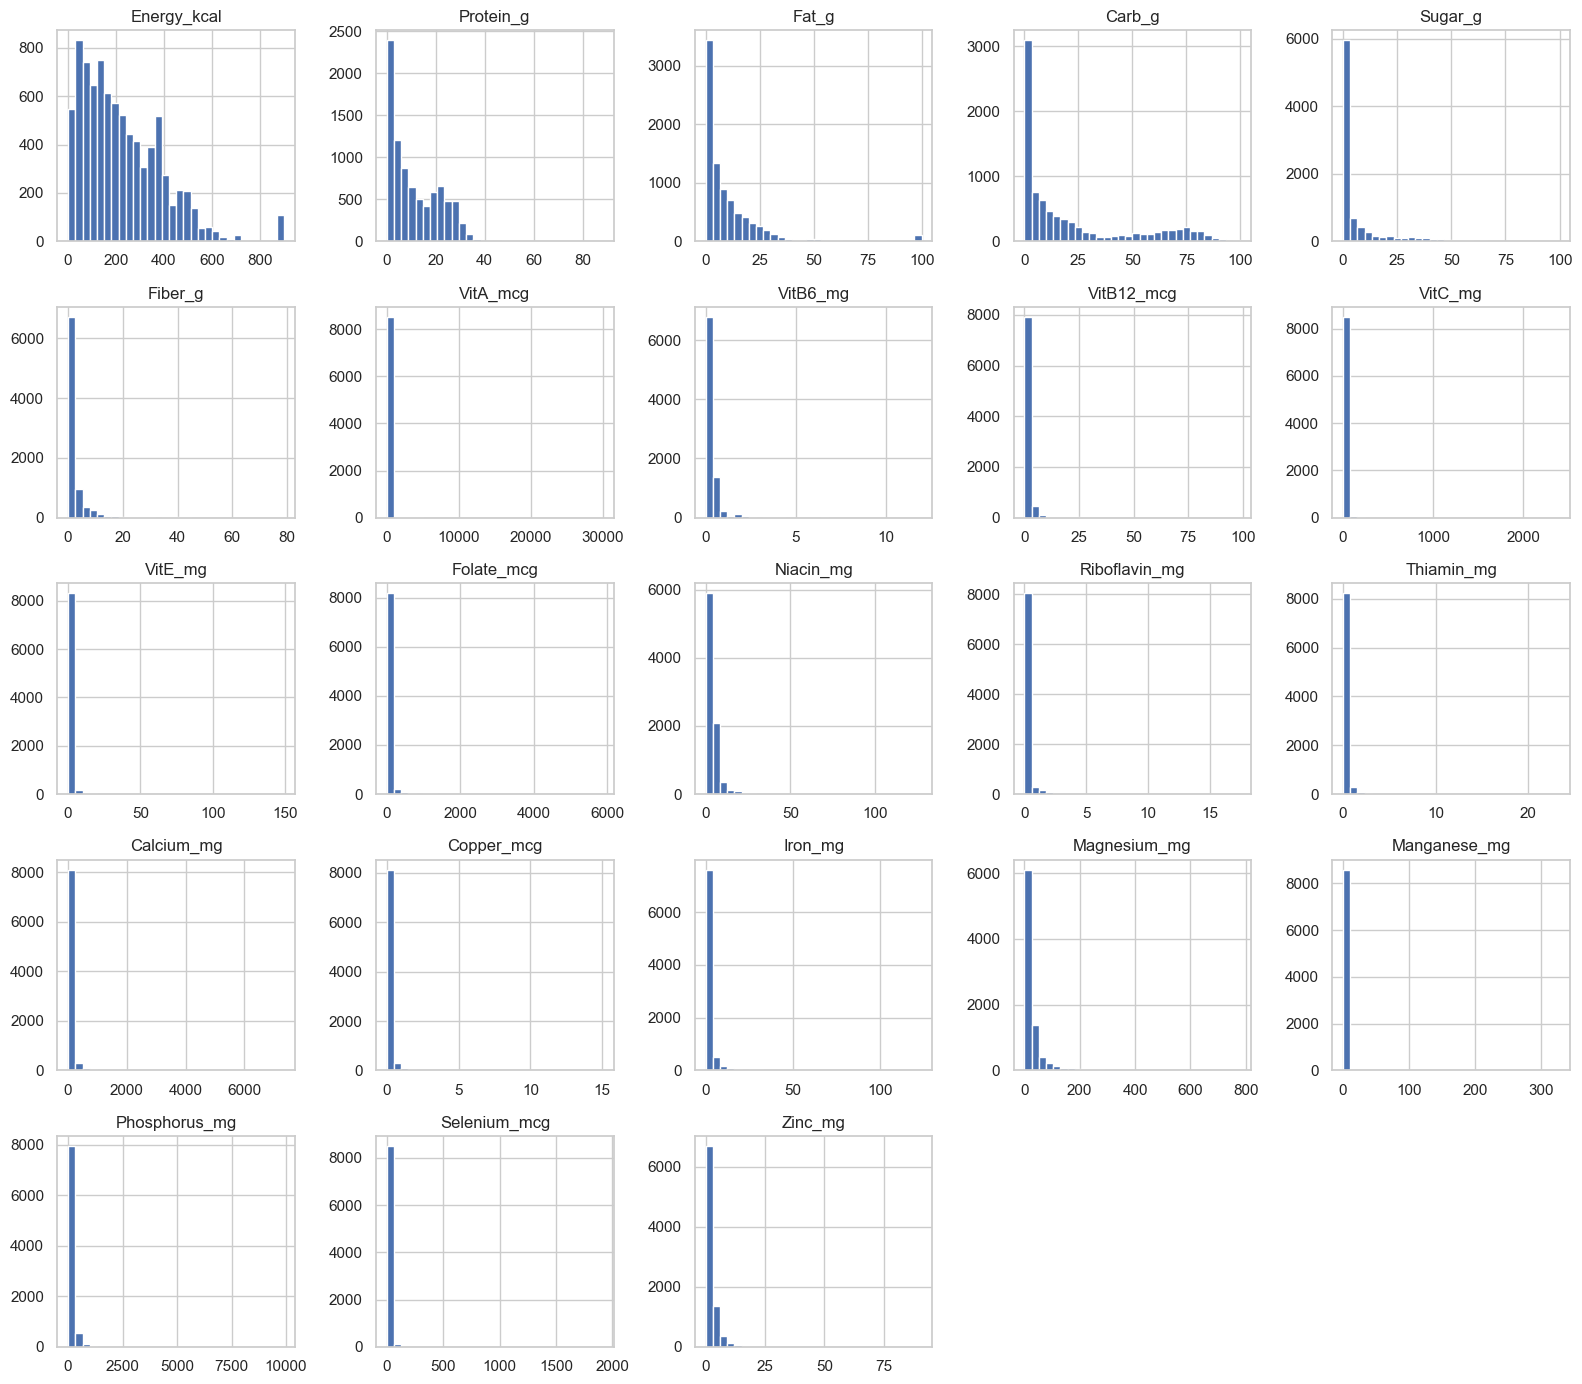

Manganese_mg     39.741772
Selenium_mcg     38.207299
VitC_mg          30.907462
VitA_mcg         24.090421
Phosphorus_mg    18.553944
Thiamin_mg       17.510062
Copper_mcg       15.943149
VitE_mg          13.849434
Calcium_mg       13.427978
VitB12_mcg       13.034297
Riboflavin_mg    11.312592
Folate_mcg       10.327038
Zinc_mg           9.629128
VitB6_mg          7.557554
Iron_mg           6.839288
Niacin_mg         6.435334
Fiber_g           5.793241
Magnesium_mg      5.565037
Fat_g             3.306166
Sugar_g           2.953324
Protein_g         1.170610
Energy_kcal       1.168243
Carb_g            1.157211
dtype: float64

log1p en variables con sesgo >1; imputación mediana de nulos. Filas preservadas.


In [6]:
X.hist(figsize=(16,14),bins=30); plt.tight_layout(); plt.show()
display(X.skew().sort_values(ascending=False))
skewed=X.columns[X.skew()>1].tolist()
assert (X[skewed].dropna()>=0).all().all()
X[skewed]=np.log1p(X[skewed])
X=pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X),columns=X.columns,index=X.index)
print('log1p en variables con sesgo >1; imputación mediana de nulos. Filas preservadas.')

### Ejercicio 6: Estandarizado
Estandariza cada variable. (No es necesario que dividas en train y test por simplificar).

In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
assert np.isfinite(X_scaled).all()

### Ejercicio 7: Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [8]:
pca=PCA().fit(X_scaled)
print('Componentes:',pca.n_components_)

Componentes: 23


### Ejercicio 8

Muestra en un dataframe la relación de cada componente con cada feature. En general, este paso no lo haremos salvo que sea necesario a posteriori explicar la influencia de alguna componente en función de las features originales, pero ahora, muéstralas.

In [9]:
loadings=pd.DataFrame(pca.components_,columns=X.columns,index=[f'PC{i+1}' for i in range(pca.n_components_)])
display(loadings)
print('Coeficientes de las combinaciones lineales; el signo global de una componente es arbitrario.')

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
PC1,0.198045,0.277927,0.148024,0.002898,-0.026550,0.074429,0.079993,0.263414,0.215148,-0.024158,...,0.266736,0.229400,0.154403,0.188309,0.281809,0.275671,0.139021,0.295597,0.247376,0.298978
PC2,0.005434,-0.242246,-0.150170,0.439120,0.320255,0.388059,0.109656,0.007442,-0.236848,0.256138,...,0.072566,0.160926,0.204121,0.136707,0.124534,0.112675,0.259182,-0.061638,-0.225185,-0.159530
PC3,0.522265,0.079023,0.473911,0.210881,0.184202,0.136179,-0.292311,-0.159116,-0.185990,-0.394600,...,-0.096958,0.057955,-0.093723,-0.040051,0.039002,-0.073287,0.029160,-0.016400,-0.062524,-0.039190
PC4,0.064251,-0.132056,0.032874,0.038051,0.281229,-0.081251,0.086504,0.312399,0.232704,0.153351,...,0.352801,0.307120,-0.208702,-0.270591,0.124226,-0.319855,-0.327222,-0.230474,-0.164419,-0.026426
PC5,0.148431,-0.074988,0.335097,-0.094996,0.089666,-0.196324,0.544616,-0.071754,0.078367,0.127914,...,-0.046883,-0.220295,0.212893,0.008586,-0.181673,-0.044502,-0.074241,0.010867,0.095435,-0.052027
PC6,-0.056377,-0.130078,0.031900,-0.195738,-0.232627,0.056819,-0.220996,0.151959,0.055321,0.104925,...,-0.032598,-0.001320,-0.440449,0.404956,0.041904,-0.096259,0.353709,-0.273709,-0.079276,0.095311
PC7,0.056439,0.006583,0.061057,0.057248,0.124189,-0.158187,0.188459,-0.218884,0.294178,-0.082043,...,0.225303,-0.113935,0.111275,0.569171,0.176256,-0.217741,0.099441,-0.148707,-0.125677,0.076144
PC8,-0.006633,0.043613,-0.090748,-0.000223,0.484500,0.066867,-0.381964,0.084649,0.247129,0.302244,...,-0.196122,-0.395320,0.056744,0.055444,-0.003136,0.191494,-0.196760,0.103840,-0.009711,0.317642
PC9,-0.056684,0.127038,0.172536,-0.178933,-0.382132,0.168389,-0.041751,0.105078,-0.071421,0.227712,...,-0.029489,0.049271,0.489771,-0.135641,0.204857,-0.019208,0.041856,-0.019741,-0.397578,0.045342
PC10,0.295080,0.017928,0.318727,0.035122,-0.210174,-0.101103,-0.080107,-0.183531,-0.065568,0.639078,...,-0.088774,-0.001610,-0.233598,0.020123,0.103469,0.016090,-0.165279,0.021910,-0.085098,-0.002007


Coeficientes de las combinaciones lineales; el signo global de una componente es arbitrario.


### Ejercicio 9: Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

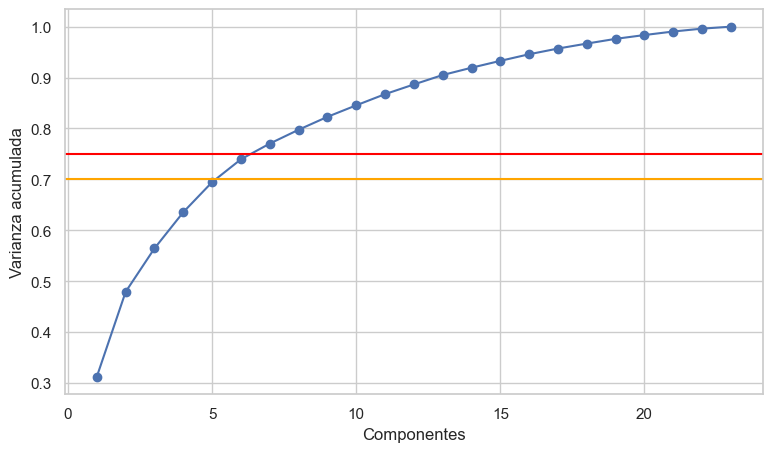

Para >=70%: 6 para >=75%: 7
Elijo el mínimo que alcanza 70%; varianza: 0.7395389215549495


In [10]:
cumulative=pca.explained_variance_ratio_.cumsum()
plt.plot(np.arange(1,len(cumulative)+1),cumulative,'o-'); plt.axhline(.70,color='orange'); plt.axhline(.75,color='red'); plt.xlabel('Componentes'); plt.ylabel('Varianza acumulada'); plt.show()
n70=int(np.searchsorted(cumulative,.70)+1); n75=int(np.searchsorted(cumulative,.75)+1)
print('Para >=70%:',n70,'para >=75%:',n75)
n_components=n70
print('Elijo el mínimo que alcanza 70%; varianza:',cumulative[n_components-1])

### Ejercicio 10: Reducción de features

Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [11]:
pca_reduced=PCA(n_components=n_components)
reduced=pd.DataFrame(pca_reduced.fit_transform(X_scaled),index=df.index,columns=[f'PC{i+1}' for i in range(n_components)])
assert reduced.shape==(len(df),n_components)
display(reduced.head()); print(reduced.shape)

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.139032,-0.968019,1.463988,0.270872,4.066991,0.307222
1,-2.106485,-0.909501,1.480580,0.263240,4.032459,0.348613
2,-3.267830,-1.138430,2.042335,1.175421,4.071722,1.326607
3,1.525964,-1.264102,-0.136013,-0.929808,2.430444,-2.095054
4,1.240712,-1.204120,-0.004729,-1.192002,2.691725,-2.341876


(8618, 6)
